In [1]:
!hostnamectl

 Static hostname: gpue07.delta.ncsa.illinois.edu
       Icon name: computer-server
         Chassis: server 🖳
      Machine ID: 7160fa58ed57460fad63c00d1f2ce1bc
         Boot ID: 5a02c0e14c05484e82dbc592d828c891
Operating System: ]8;;https://www.redhat.com/Red Hat Enterprise Linux 9.4 (Plow)]8;;     
     CPE OS Name: cpe:/o:redhat:enterprise_linux:9::baseos
          Kernel: Linux 5.14.0-427.91.1.el9_4.x86_64
    Architecture: x86-64
Firmware Version: CUXD670_5.32_v2.06


In [ ]:
# # Check JAX sees the GPU
# import jax
# print(jax.devices())  # should show CudaDevice(id=0)
# print(jax.default_backend())  # should show 'gpu'

# # Check CUDA version
# import subprocess
# print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

# # Check JAX/jaxlib versions
# import jaxlib
# print(f"JAX version: {jax.__version__}")
# print(f"jaxlib version: {jaxlib.__version__}")

# # Quick GPU computation test
# import jax.numpy as jnp
# x = jnp.ones((1000, 1000))
# print(f"Array device: {x.devices()}")  # should show CudaDevice

In [12]:
# tmp 
import os
tmp_dir = '/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp'
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=8"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Cache compiled kernels to disk (create this directory first)
cache_dir = os.path.join(tmp_dir, "asachan_jax_cache")
os.makedirs(cache_dir, exist_ok=True)
os.environ["JAX_COMPILATION_CACHE_DIR"] = cache_dir

In [2]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [ ]:
import os
os.chdir("/projects/bgdb/asachan/methods/OT_FM")  # adjust path if needed
from utils import *

/projects/bgdb/asachan/methods/OT_FM


In [6]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [7]:
rna_path = '/projects/bgdb/asachan/datasets/SKM_ageing_human/All_Cell_Types.h5ad'
rna_path_filtered = '/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_all_cell_types.h5ad'

In [8]:
rna_adata = sc.read_h5ad(rna_path_filtered)
rna_adata

AnnData object with n_obs × n_vars = 172396 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

In [ ]:
# subset to samples of interest
#rna_adata = rna_adata[rna_adata.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9', 'P13', 'P5', 'OM5', 'OM7'])].copy()

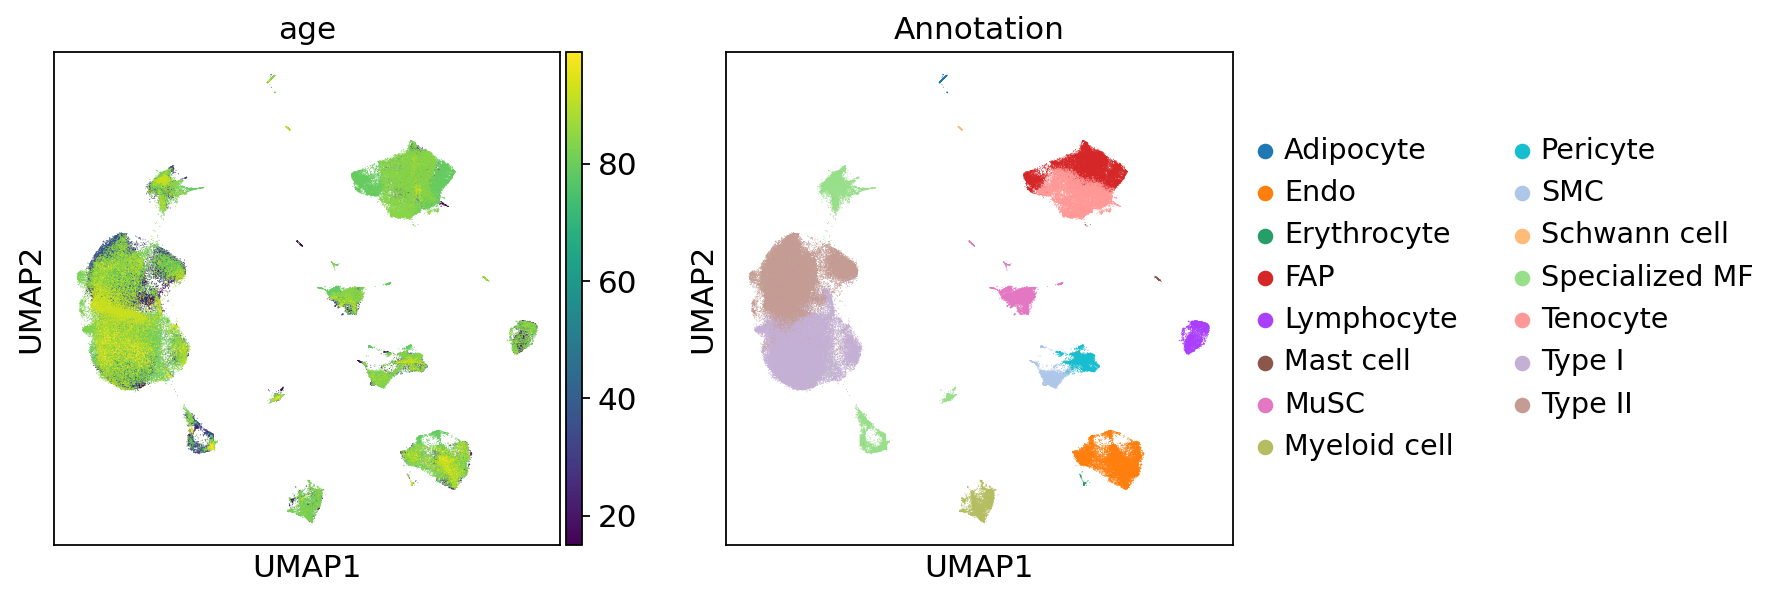

In [9]:
sc.pl.umap(rna_adata, color=['age', 'Annotation'])

In [16]:
#subset to cell types of interest
#rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II', 'MuSC', 'FAP', 'Specialized MF'])].copy()
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II'])].copy()

#### Lower bound on number of cells per age

In [17]:
age_counts = rna_adata.obs['age'].value_counts()
valid_ages = age_counts[age_counts >= 500].index

rna_adata = rna_adata[rna_adata.obs['age'].isin(valid_ages)].copy()

# # Verify
print(rna_adata.obs['age'].value_counts())

age
15.0    10004
34.0     8633
80.0     5550
45.0     4735
92.0     4657
82.0     3285
18.0     2269
38.0     1807
84.0     1594
89.0     1155
88.0      767
79.0      726
85.0      505
Name: count, dtype: int64


#### Upper bound on number of cells per age

In [18]:
n_cells_downsample = 5000
adatas = []

for age, idx in rna_adata.obs.groupby('age').groups.items():
    subset = rna_adata[idx].copy()
    if subset.shape[0] > n_cells_downsample:
        sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
    adatas.append(subset)

rna_adata = ad.concat(adatas)
del adatas

# Verify
print(rna_adata.obs['age'].value_counts())

age
15.0    5000
34.0    5000
80.0    5000
45.0    4735
92.0    4657
82.0    3285
18.0    2269
38.0    1807
84.0    1594
89.0    1155
88.0     767
79.0     726
85.0     505
Name: count, dtype: int64


In [19]:
rna_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation
CELL2804_N1_2_1,YM1_Sem2,6003.421625,1970,YM1,0.110102,15.0,snRNA,Male,China,young_pop,Type II
CELL1942_N1_1_2_1,YM1_Gluto3,10190.643128,2623,YM1,0.005279,15.0,snRNA,Male,China,young_pop,Type II
CELL440_N3_2_2_1,YM1_Sem1,9941.586809,2915,YM1,0.000971,15.0,snRNA,Male,China,young_pop,Type II
CELL5403_N1_1_2_1,YM1_Gluto3,3001.286265,981,YM1,0.187862,15.0,snRNA,Male,China,young_pop,Type II
CELL3980_N1_1_1_2_1,YM1_Gluto1,3780.406782,1211,YM1,0.234523,15.0,snRNA,Male,China,young_pop,Type II
...,...,...,...,...,...,...,...,...,...,...,...
CELL3221_N1_2_2_9_1,P3_6,1057.637670,608,P3,0.787137,92.0,snRNA,Female,Spain,old_pop,Type II
CELL3437_N1_2_2_9_1,P3_6,1031.700242,537,P3,1.874409,92.0,snRNA,Female,Spain,old_pop,Type II
CELL3342_N1_2_2_9_1,P3_6,1079.906438,564,P3,0.321089,92.0,snRNA,Female,Spain,old_pop,Type II
CELL2837_N1_2_2_9_1,P3_6,1240.637093,680,P3,0.834310,92.0,snRNA,Female,Spain,old_pop,Type II


In [20]:
#load adata with sub cluster labels
type2_sub_cluster = sc.read_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/Myofiber_scsn_RNA.h5ad')
type2_sub_cluster

AnnData object with n_obs × n_vars = 150894 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII'
    var: 'features'
    uns: 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'rank_genes_groups'
    obsm: 'X_umap'

In [22]:
type2_sub_cluster.obs['Annotation'].value_counts()

Annotation
Type I         65605
Type II        49814
ENOX1+ (II)     9963
ID1+ (I)        6569
TNNT2+ (I)      4601
DCLK1+ (I)      4576
ID1+ (II)       3035
MTJ             2676
SAA2+ (II)      2368
DCLK1+ (II)      708
SAA2+ (I)        630
NMJ              264
TNNT2+ (II)       85
Name: count, dtype: int64

In [23]:
subset_adata = type2_sub_cluster[type2_sub_cluster.obs['Annotation'].isin(['Type II', 'ENOX1+ (II)', 'ID1+ (II)', 'SAA2+ (II)', 'DCLK1+ (II)', 'TNNT2+ (II)'])]

In [ ]:
# # save 
#rna_adata.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/type2_samples_oi.h5ad')

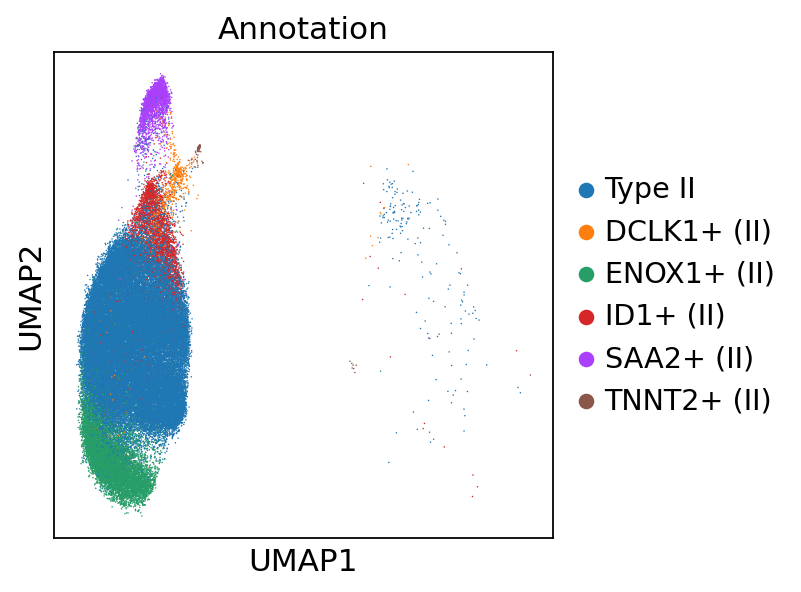

In [25]:
sc.pl.umap(subset_adata, color=['Annotation'])

In [ ]:
# make temporal info numeric
def adapt_time(x):
    if x["age_pop"] == "young_pop":
        return 1.5
    if x["age_pop"] == "old_pop":
        return 3.5
    raise ValueError

rna_adata.obs["age_pop"] = rna_adata.obs.apply(adapt_time, axis=1).astype("category")

In [ ]:
rna_adata.obs['age_pop'].value_counts()

In [ ]:
# instantiate temporal OT problem
tp0 = TemporalProblem(rna_adata)
tp0 = tp0.prepare(time_key="age_pop")

In [ ]:
import networkx as nx

batch_column = "age_pop"
batch1, batch2 = 1.5, 3.5

indices = np.where(
    (rna_adata.obs[batch_column] == batch1) | (rna_adata.obs[batch_column] == batch2)
)[0]

adata_subset = rna_adata[indices]
sc.pp.neighbors(adata_subset, n_neighbors=30, use_rep="X_pca")

G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
assert nx.is_connected(G)

# if graph not connect check if there is a major disconnectivity due to batch effect in the latent space
# n_components = nx.number_connected_components(G)
# print(f"Number of connected components: {n_components}")
# # Check sizes of each component
# sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
# print(f"Component sizes: {sizes}")

In [ ]:
df = pd.DataFrame(
    index=adata_subset.obs_names,
    columns=adata_subset.obs_names,
    data=adata_subset.obsp["connectivities"].todense().astype("float"),
)

In [ ]:
t1, t2 = 1.5, 3.5
prob = tp0[t1, t2]
expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)
Gdf = df.loc[expected, expected].astype(float)
prob.set_graph_xy(Gdf, t=100.0)

In [ ]:
import scanpy as sc
sc.settings.verbosity = 3  # shows more detail
# epsilon: entropic regularization strength
#batch_size is for sinkhorn iterations, the grpah omputation and transfer to gpu (compilation) takes most time
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7, batch_size=5000) 

### Save objects after computation

In [ ]:
import cloudpickle
with open(f'{tmp_dir}/tp0_5k_type2_plus_soi.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

In [ ]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)

sp.save_npz(os.path.join(tmp_dir, "T_1.5_3.5_soi.npz"), T_15_35_csr)

## Visualize cell clusters of interest

In [14]:
import cloudpickle
# load pickle
with open(f'{tmp_dir}/tp0_5k_type2.pkl', 'rb') as f:
    tp0 = cloudpickle.load(f)

In [15]:
rna_adata.obs["age"] = rna_adata.obs["age"].astype("category")
order_chronological = rna_adata.obs["age"].cat.categories.tolist()
order_chronological

[15.0,
 17.0,
 18.0,
 29.0,
 34.0,
 38.0,
 45.0,
 77.0,
 79.0,
 80.0,
 82.0,
 84.0,
 85.0,
 88.0,
 89.0,
 92.0,
 99.0]

In [ ]:
# # cell types of interest
# rna_adata.obs['Annotation'] = rna_adata.obs['Annotation'].astype("category")
# order_cell_types = rna_adata.obs['Annotation'].cat.categories.tolist()
# order_cell_types

In [ ]:
#aggregating the transport matrix by chronological age
# ANSCESTORS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=False,
    key_added="transitions_1.5_3.5_large",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_large",
)
plt.tight_layout()
plt.show()

In [ ]:
#aggregating the transport matrix by chronological age
# DESCENDANTS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=True,
    key_added="transitions_1.5_3.5_soi",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_soi",
)
plt.tight_layout()
plt.show()

In [ ]:
tp0.pull(source=1.5, target=3.5, data="Annotation")
fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

mpl.pull(
    tp0,
    time_points=[1.5],
    basis="X_umap",
    ax=axes[0],
    title=["Myofibers at time 1.5 (young_pop)"],
)

mpl.pull(
    tp0,
    time_points=[3.5],
    basis="X_umap",
    ax=axes[1],
    title=["Myofibers at time 3.5 (old_pop)"],
)

fig.subplots_adjust(wspace=0.3)

In [ ]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"Annotation": order_cell_types},
    target_groups={"Annotation": order_cell_types},
    threshold=0.05,
    order_annotations=order_cell_types[::-1],
    normalize=True,
)

In [ ]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

## Identifying driver genes

In [ ]:
X_orig = tp0.adata.X.copy()

#check mean and min and max of X
print(X_orig.mean(), X_orig.min(), X_orig.max())

In [ ]:
sc.pp.normalize_total(tp0.adata)
sc.pp.log1p(tp0.adata)

In [ ]:
# Get driver TFs for age-chronological_young/cell-cluster-2 (young) → age-chronological_old/cell-cluster-1 (old) transition
drivers_spec_mf_type2, top_pos, top_neg = driver_tfs_for_subset(
    tp=tp0,
    old_cell_cluster='Type II',
    young_cell_cluster='Specialized MF',
    cell_cluster_col='Annotation',
    t_young=1.5,
    t_old=3.5,
)